In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Load pothole work order data
potholes = gpd.read_file("../data/raw/Street_Pothole_Work_Orders_-_Closed_(Dataset).geojson")

print(f"data loaded: {len(potholes)} rows x {len(potholes.columns)} columns")
potholes.head()

data loaded: 401594 rows x 19 columns


,:id,:version,:created_at,:updated_at,defnum,initby,housenum,oft,onfacename,onprimname,frmprimnam,toprimname,specloc,boro,source,rptdate,rptclosed,shape_leng,geometry
0,row-jx8m.gdpq-y3ua,rv-6qef~j48j_5b9e,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2004041154,YRD,None,373480377030377030,ROCKAWAY PY,ROCKAWAY PARKWAY,BELT PARKWAY,BELT PARKWAY,None,B,YRD,2004-02-08,2023-01-27,557.690464852,"MULTILINESTRING ((-73.88643 40.63078, -73.8860..."
1,row-mi7k_dc5y~e33f,rv-dzgk~n5m2_gvx9,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2004287021,CSC,None,318630377030377030,BEDFORD AV,BEDFORD AVENUE,BELT PARKWAY,BELT PARKWAY,SB ON BEDFORD_UNDERNEATH OVERPASS,B,CTZ,2004-10-13,2013-02-14,109.124234309,"MULTILINESTRING ((-73.94381 40.58499, -73.9438..."
2,row-8wxg_rmxu_et2s,rv-wxhh_pdb9.2rzt,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2006085009,CSC,None,306380308480308530,13 AV,13 AVENUE,38 STREET,39 STREET,I/F/O B16 BUS STOP,B,CTZ,2006-03-26,2014-10-11,260.495098096,"MULTILINESTRING ((-73.98571 40.64119, -73.9862..."
3,row-w2jj_j5em~gjk4,rv-bwbx_nhbh.sbcs,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2007166005,CSC,1688,342730355530375430,FULTON ST,FULTON STREET,LEWIS AVENUE,SCHENECTADY AVENUE,POTHOLE NEAR CURB I/F/O ADDRESS,B,CTZ,2007-06-15,2011-01-14,549.255973307,"MULTILINESTRING ((-73.93487 40.67959, -73.9343..."
4,row-mje4.qtar~cgsu,rv-kse4.pez2_yrib,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2009352004,CSC,45,380030331530342730,ST FELIX ST,ST FELIX STREET,DEKALB AVENUE,FULTON STREET,"4"" DEEP",B,CTZ,2009-12-18,2010-01-06,836.436669174,"MULTILINESTRING ((-73.97794 40.68981, -73.9775..."


In [3]:
# Clean pothole work order data and cast data types
potholes = potholes.drop(columns = [col for col in potholes.columns if col[0] == ":"]) # drop metadata cols 

dtype_schema = {
    "numeric": ["shape_leng"],
    "category": ["boro"],
    "datetime": ["rptdate", "rptclosed"],
    "object": ["defnum", "initby", "housenum", "oft", "onfacename", "onprimname", "frmprimnam", "toprimname", "specloc", "source"]
}

for col in potholes.columns:
    if col == "geometry":
        continue # leave geometry untouched
    elif col in dtype_schema["numeric"]:
        potholes[col] = pd.to_numeric(potholes[col]) 
    elif col in dtype_schema["category"]:
        potholes[col] = potholes[col].astype("category") 
    elif col in dtype_schema["datetime"]:
        potholes[col] = pd.to_datetime(potholes[col])
    elif col in dtype_schema["object"]:
        potholes[col] = potholes[col].astype(str)
    else: 
        print(f"Warning: {col} not in schema")

# Create new cols
potholes["response_time"] = ((potholes["rptclosed"] - potholes["rptdate"])).dt.days

In [4]:
# Load 311 data
service_requests = gpd.read_file("../data/raw/311_Service_Requests_from_2020_to_Present.geojson")

print(f"data loaded: {len(service_requests)} rows x {len(service_requests.columns)} columns")
service_requests.head()

data loaded: 288074 rows x 52 columns


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,longitude,:id,:version,:created_at,:updated_at,:@computed_region_f5dn_yrer,:@computed_region_yeji_bk3q,:@computed_region_sbqj_enih,:@computed_region_92fq_4b7q,geometry
0,68699632,2026-04-18 02:09:46,2026-04-18 02:09:46,DOT,Department of Transportation,Street Condition,Pothole,None,None,11421,...,None,row-35y3.8vi3_2s3u,rv-nni4-tzq5.3ypb,2026-04-19 01:32:50.107000+00:00,2026-04-19 01:35:13.119000+00:00,None,None,None,None,None
1,68696698,2026-04-18 01:18:36,2026-04-18 01:18:36,DOT,Department of Transportation,Street Condition,Pothole,None,None,11422,...,None,row-keg4~5h6p_qdep,rv-bp28~knaf.tmke,2026-04-19 01:32:50.107000+00:00,2026-04-19 01:35:13.119000+00:00,None,None,None,None,None
2,68705915,2026-04-18 01:18:02,NaT,DOT,Department of Transportation,Street Condition,Pothole,None,None,11427,...,None,row-3n94_2ndf-ix38,rv-5bhi.hiq9~r7rd,2026-04-19 01:32:50.107000+00:00,2026-04-19 01:35:14.515000+00:00,None,None,None,None,None
3,68703016,2026-04-18 01:16:52,NaT,DOT,Department of Transportation,Street Condition,Pothole,None,None,11429,...,None,row-zfam-8n74.8jmk,rv-9gdy-bmte-sac2,2026-04-19 01:32:50.107000+00:00,2026-04-19 01:35:13.119000+00:00,None,None,None,None,None
4,68705916,2026-04-18 01:16:15,NaT,DOT,Department of Transportation,Street Condition,Pothole,None,None,11423,...,None,row-uxvg_7dzx_dpc7,rv-kim7.rzvi.rs8u,2026-04-19 01:32:50.107000+00:00,2026-04-19 01:35:14.515000+00:00,None,None,None,None,None


In [5]:
# Clean 311 data and dedupe
service_requests = service_requests.drop(columns = [col for col in service_requests.columns if col[0] == ":"]) # drop metadata cols 

# Get duplicates by street name, cross streets, and borough, within 1 week of eachother 
sr_filtered = service_requests.dropna(subset=["street_name", "cross_street_1", "cross_street_2", "borough"]).copy()

sr_filtered["date_only"] = sr_filtered["created_date"].dt.floor("D")
sr_filtered["period"] = (sr_filtered["created_date"] - sr_filtered["created_date"].min()).dt.days // 7

sr_duplicates = sr_filtered[sr_filtered.duplicated(
    subset=["street_name", "cross_street_1", "cross_street_2", "borough", "period"], 
    keep="first"
)] # Identified 29302 likely duplicates across 3130 streets with this criteria

# Deduplicate based on unique keys of identified likely duplicates above
service_requests = service_requests[~service_requests["unique_key"].isin(sr_duplicates["unique_key"])]

In [6]:
# Create pothole work order rollups
potholes_clsd_by_year = (
    potholes.groupby(potholes["rptclosed"].dt.to_period('Y').rename("year"), observed=False, dropna=False)
    .agg(count = ("defnum","count"))
    .reset_index()
)

potholes_clsd_by_monthyear = (
    potholes.groupby(potholes["rptclosed"].dt.to_period('M').rename("month_year"), observed=False, dropna=False)
    .agg(count = ("defnum","count"), mean = ("response_time", "mean"))
    .reset_index()
)

potholes_clsd_by_month = (
    potholes.groupby(potholes["rptclosed"].dt.to_period('M').rename("month_year"), observed=False, dropna=False)
    .agg(count = ("defnum","count"))
    .reset_index()
)
potholes_clsd_by_month["month"] = potholes_clsd_by_month["month_year"].dt.month
potholes_clsd_by_month["year"] = potholes_clsd_by_month["month_year"].dt.year

potholes_clsd_by_week = (
    potholes.groupby(potholes["rptclosed"].dt.to_period('W').rename("week"), dropna=False)
    .agg(count=("defnum", "count"))
    .reset_index()
)

potholes_rptd_by_monthyear = (
    potholes.groupby(potholes["rptdate"].dt.to_period('M').rename("month_year"), observed=False, dropna=False)
    .agg(count = ("defnum","count"))
    .reset_index()
)
potholes_rptd_by_monthyear = potholes_rptd_by_monthyear[potholes_rptd_by_monthyear["month_year"] > min(potholes["rptclosed"].dt.to_period('M'))] # clip to match closed date range for easy comparison


# Create 311 rollups
service_requests_by_year = (
    service_requests.groupby(service_requests["created_date"].dt.to_period('Y').rename("year"), observed=False, dropna=False)
    .agg(count = ("unique_key","count"))
    .reset_index()
)

service_requests_by_monthyear = (
    service_requests.groupby(service_requests["created_date"].dt.to_period('M').rename("month_year"), observed=False, dropna=False)
    .agg(count = ("unique_key","count"))
    .reset_index()
)

service_requests_by_week = (
    service_requests.groupby(service_requests["created_date"].dt.to_period('W').rename("week"), dropna=False)
    .agg(count=("unique_key", "count"))
    .reset_index()
)

# Clip to 2025 for pre-Mamdani baseline
service_requests_by_week = service_requests_by_week[
    (service_requests_by_week["week"].dt.end_time <= "2025-12-31")
]

potholes_clsd_by_week = potholes_clsd_by_week[
    (potholes_clsd_by_week["week"].dt.end_time <= "2025-12-31")
]

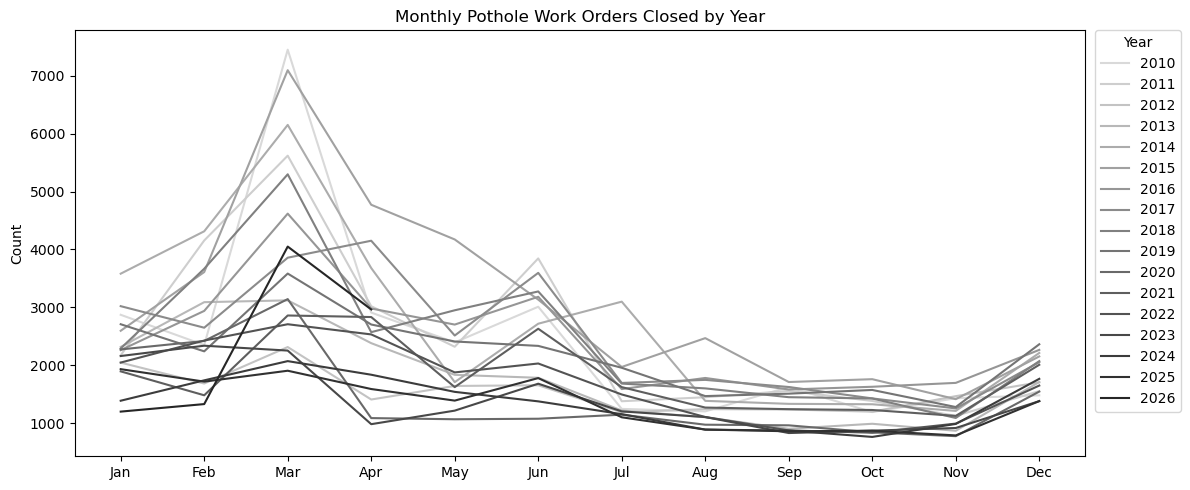

In [7]:
# Plot monthly pothole closures by year
years = sorted(potholes_clsd_by_monthyear["month_year"].dt.year.dropna().unique())
greys = plt.cm.gray(np.linspace(0.85, 0.15, len(years))) 

fig, ax = plt.subplots(figsize=(12, 5))

for year, color in zip(years, greys):
    group = potholes_clsd_by_monthyear[potholes_clsd_by_monthyear["month_year"].dt.year == year]
    ax.plot(group["month_year"].dt.month, group["count"], label=year, color=color)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend(title="Year", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax.set_title("Monthly Pothole Work Orders Closed by Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

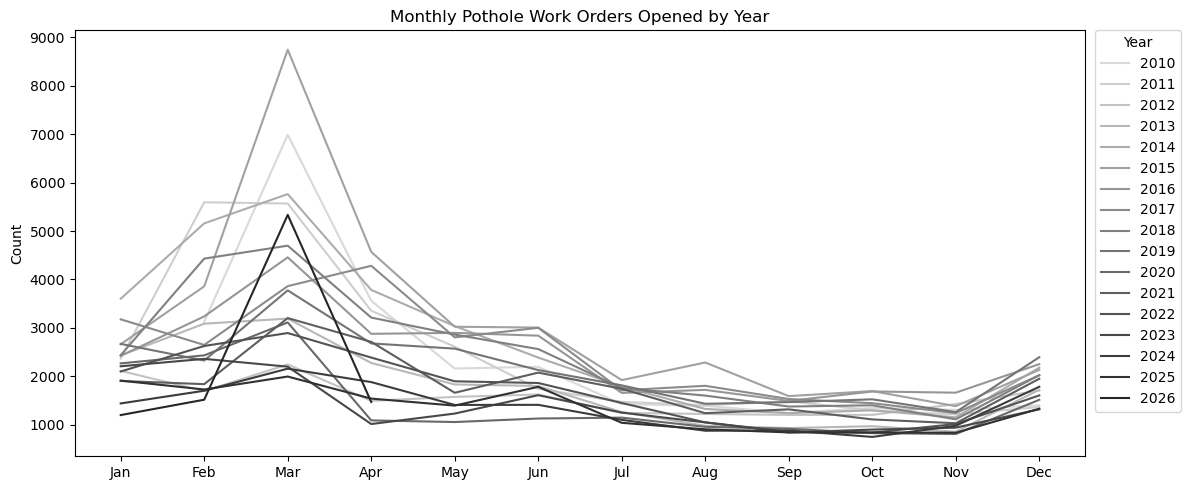

In [8]:
# Plot monthly pothole work orders opened by year
fig, ax = plt.subplots(figsize=(12, 5))

for year, color in zip(years, greys):
    group = potholes_rptd_by_monthyear[potholes_rptd_by_monthyear["month_year"].dt.year == year]
    ax.plot(group["month_year"].dt.month, group["count"], label=year, color=color)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend(title="Year", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax.set_title("Monthly Pothole Work Orders Opened by Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

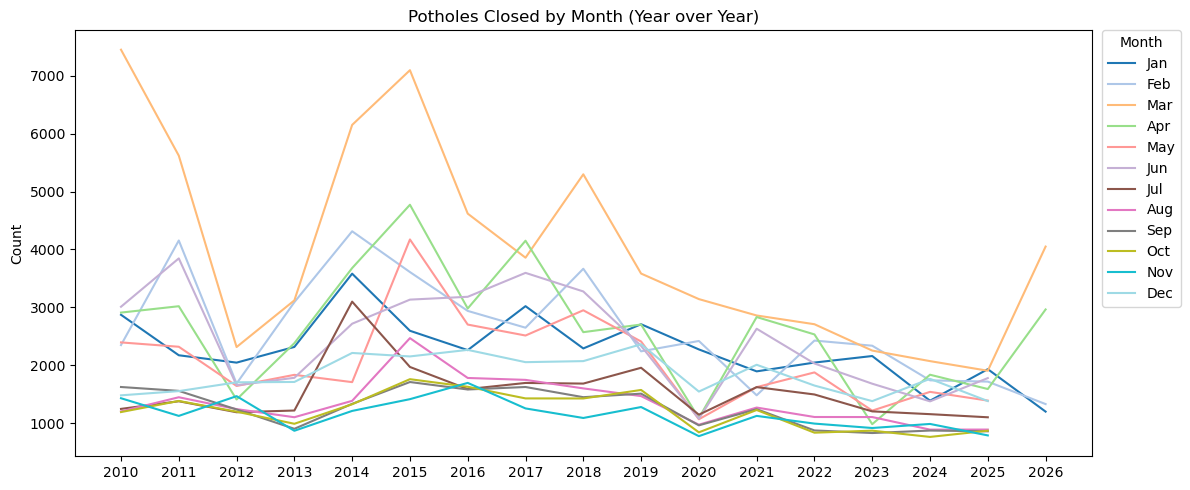

In [9]:
# Plot potholes closed by month year over year
cmap = plt.get_cmap("tab20", 12)

fig, ax = plt.subplots(figsize=(12, 5))

for month, label in enumerate(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], start=1):
    df_month = potholes_clsd_by_month[potholes_clsd_by_month["month"] == month]
    ax.plot(df_month["year"], df_month["count"], label=label, color=cmap(month - 1))

ax.set_xticks(sorted(potholes_clsd_by_month["year"].unique()))
ax.legend(title="Month", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax.set_title("Potholes Closed by Month (Year over Year)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

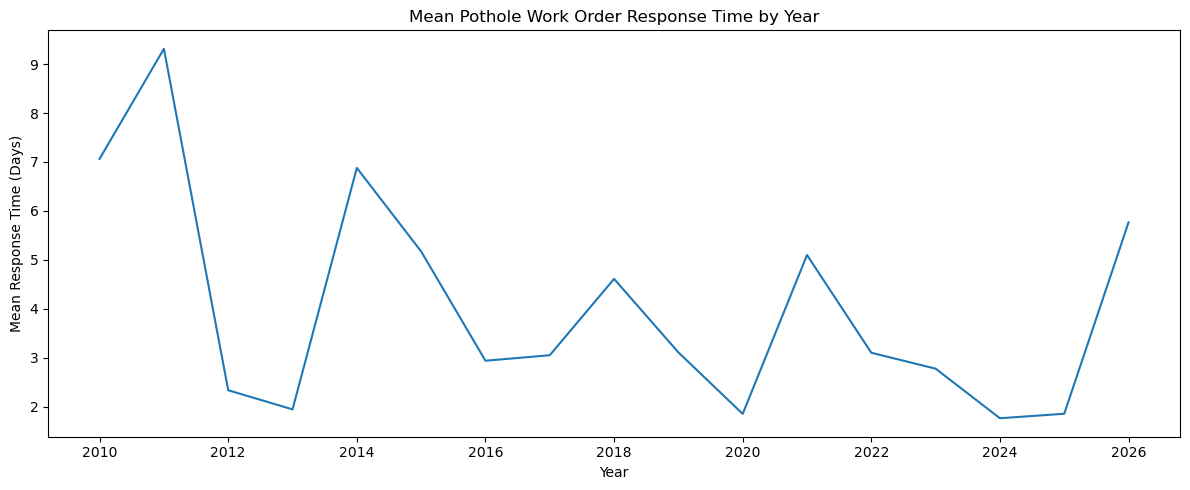

In [10]:
# Plot mean response time from work order open to close by year
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    potholes_clsd_by_monthyear.groupby(potholes_clsd_by_monthyear["month_year"].dt.year)["mean"].mean().index,
    potholes_clsd_by_monthyear.groupby(potholes_clsd_by_monthyear["month_year"].dt.year)["mean"].mean().values,
)

ax.set_title("Mean Pothole Work Order Response Time by Year")
ax.set_ylabel("Mean Response Time (Days)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

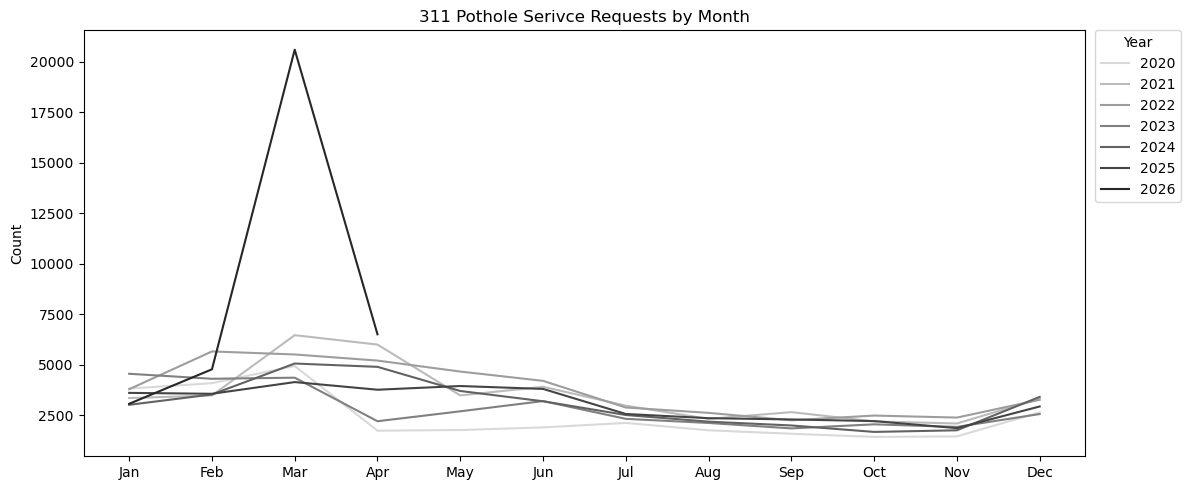

In [11]:
# Plot 311 monthly pothole complaints by year
years = sorted(service_requests_by_monthyear["month_year"].dt.year.dropna().unique())
greys = plt.cm.gray(np.linspace(0.85, 0.15, len(years))) 

fig, ax = plt.subplots(figsize=(12, 5))

for year, color in zip(years, greys):
    group = service_requests_by_monthyear[service_requests_by_monthyear["month_year"].dt.year == year]
    ax.plot(group["month_year"].dt.month, group["count"], label=year, color=color)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend(title="Year", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax.set_title("311 Pothole Serivce Requests by Month")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

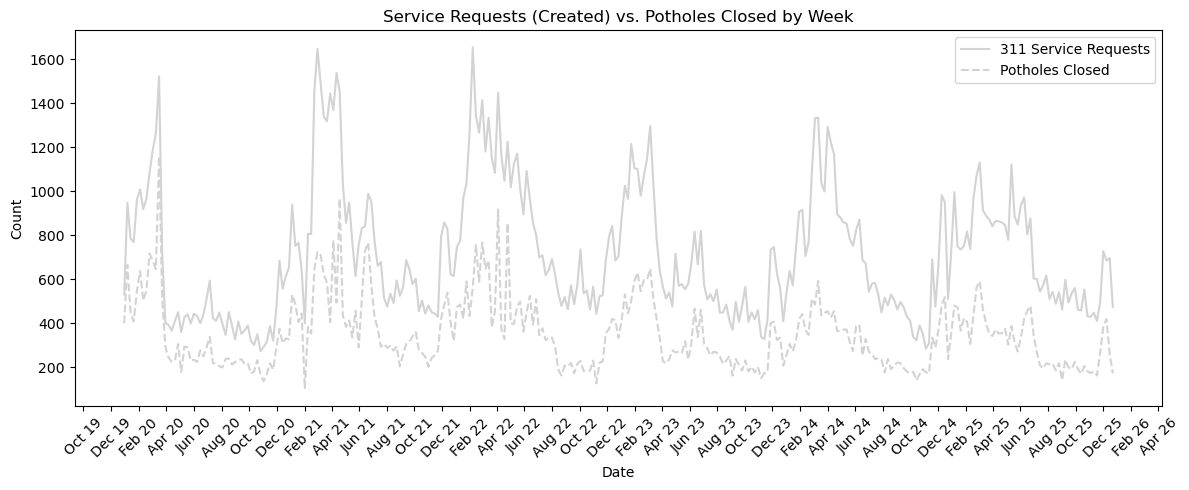

In [12]:
# Plot comparison of 311 complaints and potholes closed by week
potholes_clsd_by_week_2020onward = potholes_clsd_by_week[potholes_clsd_by_week["week"].dt.year >= 2020]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(service_requests_by_week["week"].dt.to_timestamp(), service_requests_by_week["count"],
        label="311 Service Requests", color="lightgrey")

ax.plot(potholes_clsd_by_week_2020onward["week"].dt.to_timestamp(), potholes_clsd_by_week_2020onward["count"],
        label="Potholes Closed", color="lightgrey", linestyle="--")

ax.set_title("Service Requests (Created) vs. Potholes Closed by Week")
ax.set_xlabel("Date")
ax.set_ylabel("Count")
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# Calculate annual gaps
annual_pothole_gap = pd.DataFrame({
    "year": range(2020,2026),
    "count": (service_requests_by_year["count"].values - potholes_clsd_by_year[potholes_clsd_by_year["year"] >= min(service_requests_by_year["year"])]["count"].values)[:-1]
})

print(f"median annual backlog addition: {np.median(annual_pothole_gap["count"])}\nmean annual backlog addition: {np.mean(annual_pothole_gap["count"])}\ntotal backlog since 2020: {sum(annual_pothole_gap["count"])}")

median annual backlog addition: 20367.5
mean annual backlog addition: 19098.833333333332
total backlog since 2020: 114593


In [14]:
# Export Data
potholes_clsd_by_week.to_csv("../data/processed/nyc_potholes_filled_weekly_20-25.csv")
service_requests_by_week.to_csv("../data/processed/nyc_311_pothole_complaints_weekly_20-25.csv")